In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("/home/vivek/Downloads/EDA_Practice_Dataset.csv")
print(df)
df.head(5)

     Customer_ID   Age  Gender       City   Salary  Purchase_Amount Is_Member  \
0           1079  45.0    Male       Pune  30000.0           4000.0       Yes   
1           1011  25.0     NaN     Mumbai  60000.0           3000.0        No   
2           1005  25.0  Female  Bangalore  60000.0           1000.0       NaN   
3           1085  45.0    Male       Pune  60000.0           4000.0       NaN   
4           1065  45.0     NaN        NaN  30000.0              NaN       Yes   
..           ...   ...     ...        ...      ...              ...       ...   
105         1072  22.0     NaN       Pune  70000.0              NaN       Yes   
106         1015  50.0    Male  Bangalore  50000.0           4000.0       NaN   
107         1093  22.0  Female     Mumbai      NaN              NaN       NaN   
108         1052  40.0     NaN       Pune  50000.0           4000.0       NaN   
109         1034  22.0    Male       Pune  70000.0           4000.0        No   

    Purchase_Date  
0      

,Customer_ID,Age,Gender,City,Salary,Purchase_Amount,Is_Member,Purchase_Date
0,1079,45.0,Male,Pune,30000.0,4000.0,Yes,2023-02-15
1,1011,25.0,NaN,Mumbai,60000.0,3000.0,No,NaN
2,1005,25.0,Female,Bangalore,60000.0,1000.0,NaN,2023-11-21
3,1085,45.0,Male,Pune,60000.0,4000.0,NaN,2023-03-15
4,1065,45.0,NaN,NaN,30000.0,NaN,Yes,NaN


DATA CLEANING AND FILLING NULL VLAUES....

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer_ID      110 non-null    int64  
 1   Age              102 non-null    float64
 2   Gender           69 non-null     str    
 3   City             100 non-null    str    
 4   Salary           88 non-null     float64
 5   Purchase_Amount  85 non-null     float64
 6   Is_Member        76 non-null     str    
 7   Purchase_Date    96 non-null     str    
dtypes: float64(3), int64(1), str(4)
memory usage: 7.0 KB


In [3]:
df.isnull().sum()

Customer_ID         0
Age                 8
Gender             41
City               10
Salary             22
Purchase_Amount    25
Is_Member          34
Purchase_Date      14
dtype: int64

In [4]:
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["Age"] = df["Age"].fillna(df["Age"].mean()).astype("int")
print(df["Age"])

0      45
1      25
2      25
3      45
4      45
       ..
105    22
106    50
107    22
108    40
109    22
Name: Age, Length: 110, dtype: int64


In [5]:
df["Salary"]=pd.to_numeric(df["Salary"],errors="coerce")
df["Salary"]=df["Salary"].fillna(df["Salary"].mean())
print(df["Salary"])

0      30000.0
1      60000.0
2      60000.0
3      60000.0
4      30000.0
        ...   
105    70000.0
106    50000.0
107    50000.0
108    50000.0
109    70000.0
Name: Salary, Length: 110, dtype: float64


In [6]:
df["Purchase_Amount"]=pd.to_numeric(df["Purchase_Amount"],errors="coerce")
df["Purchase_Amount"]=df["Purchase_Amount"].fillna(df["Purchase_Amount"].mean())
print(df["Purchase_Amount"])

0      4000.000000
1      3000.000000
2      1000.000000
3      4000.000000
4      2529.411765
          ...     
105    2529.411765
106    4000.000000
107    2529.411765
108    4000.000000
109    4000.000000
Name: Purchase_Amount, Length: 110, dtype: float64


In [7]:
df.isnull().sum()

Customer_ID         0
Age                 0
Gender             41
City               10
Salary              0
Purchase_Amount     0
Is_Member          34
Purchase_Date      14
dtype: int64

In [8]:
# Geneder ko exactly fill nhi kar skte hai isliye vha "unkonwn" fill krenge ..
# city jo jada city name h column mein use 

df["Gender"]=df["Gender"].fillna("Unknown")
print(df["Gender"])

0         Male
1      Unknown
2       Female
3         Male
4      Unknown
        ...   
105    Unknown
106       Male
107     Female
108    Unknown
109       Male
Name: Gender, Length: 110, dtype: str


In [9]:
df["City"].value_counts().sort_values(ascending=False)

City
Mumbai       30
Bangalore    28
Delhi        24
Pune         18
Name: count, dtype: int64

In [10]:
df["City"]=df["City"].fillna("Mumbai")
print(df["City"])

0           Pune
1         Mumbai
2      Bangalore
3           Pune
4         Mumbai
         ...    
105         Pune
106    Bangalore
107       Mumbai
108         Pune
109         Pune
Name: City, Length: 110, dtype: str


In [11]:
df["Is_Member"].value_counts().sort_values(ascending=False)

Is_Member
Yes    48
No     28
Name: count, dtype: int64

In [12]:
df["Is_Member"]=df["Is_Member"].fillna("Yes")
print(df["Is_Member"])

0      Yes
1       No
2      Yes
3      Yes
4      Yes
      ... 
105    Yes
106    Yes
107    Yes
108    Yes
109     No
Name: Is_Member, Length: 110, dtype: str


In [13]:
df.isnull().sum()

Customer_ID         0
Age                 0
Gender              0
City                0
Salary              0
Purchase_Amount     0
Is_Member           0
Purchase_Date      14
dtype: int64

In [14]:
df["Purchase_Date"] = df["Purchase_Date"].bfill()  # backward fill null value
print(df["Purchase_Date"])

0      2023-02-15
1      2023-11-21
2      2023-11-21
3      2023-03-15
4      2023-08-29
          ...    
105    2023-01-18
106    2023-06-08
107    2023-06-08
108    2023-06-08
109    2023-02-22
Name: Purchase_Date, Length: 110, dtype: str


In [15]:
df.isnull().sum()
# all null values is filled

Customer_ID        0
Age                0
Gender             0
City               0
Salary             0
Purchase_Amount    0
Is_Member          0
Purchase_Date      0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(8)

In [17]:
df.drop_duplicates(inplace=True)

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.describe()

,Customer_ID,Age,Salary,Purchase_Amount
count,102.000000,102.000000,102.000000,102.000000
mean,1050.843137,34.705882,49705.882353,2467.704729
std,28.827498,8.936064,12778.066167,1002.049271
min,1001.000000,22.000000,30000.000000,1000.000000
25%,1026.250000,30.000000,40000.000000,2000.000000
50%,1051.500000,34.000000,50000.000000,2529.411765
75%,1074.750000,40.000000,60000.000000,3000.000000
max,1100.000000,50.000000,70000.000000,4000.000000


VISULAISATION...

In [20]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'City', 'Salary', 'Purchase_Amount',
       'Is_Member', 'Purchase_Date'],
      dtype='str')

Kis date ko sabse zyada purchase hui?

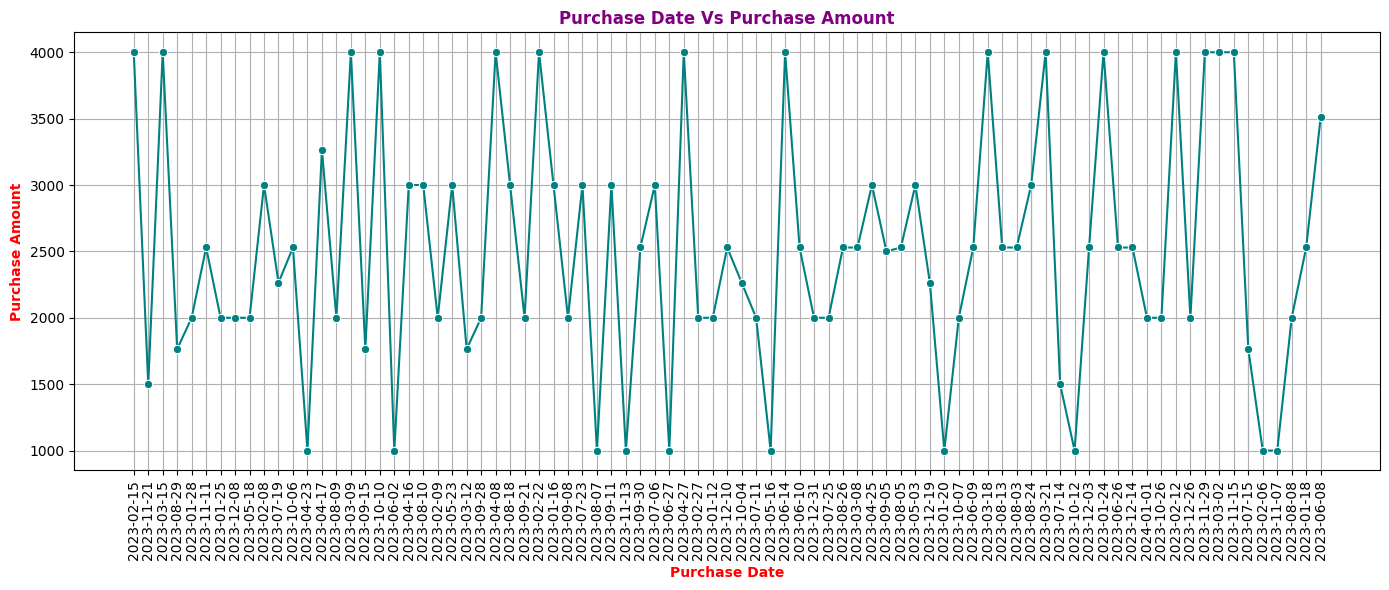

In [21]:
plt.figure(figsize=(14,6))
sns.lineplot(data=df,x="Purchase_Date",y="Purchase_Amount",color="Teal",marker="o")
plt.title("Purchase Date Vs Purchase Amount",fontweight="bold",color="purple")
plt.xlabel("Purchase Date",fontweight="bold",color="red")
plt.ylabel("Purchase Amount",fontweight="bold",color="red")
plt.grid(True)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

salary trend according to date

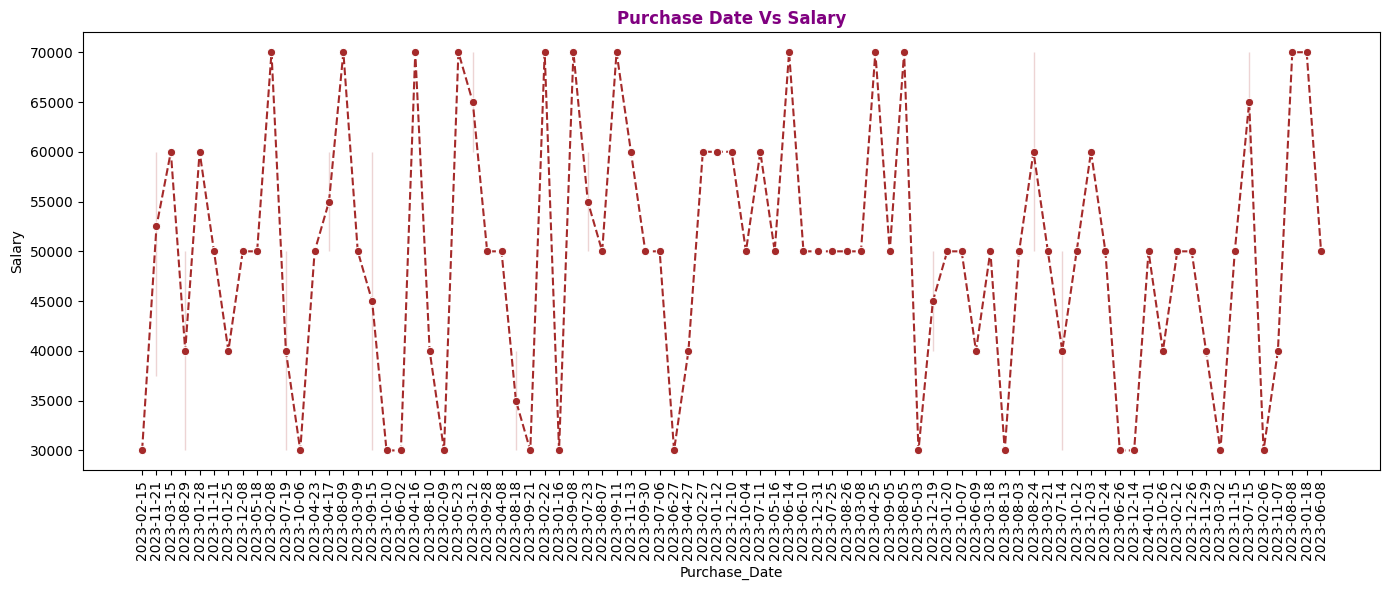

In [22]:
plt.figure(figsize=(14,6))
sns.lineplot(data=df,x="Purchase_Date",y="Salary",color="Brown",marker="o",linestyle="--")
plt.title("Purchase Date Vs Salary",fontweight="bold",color="purple")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

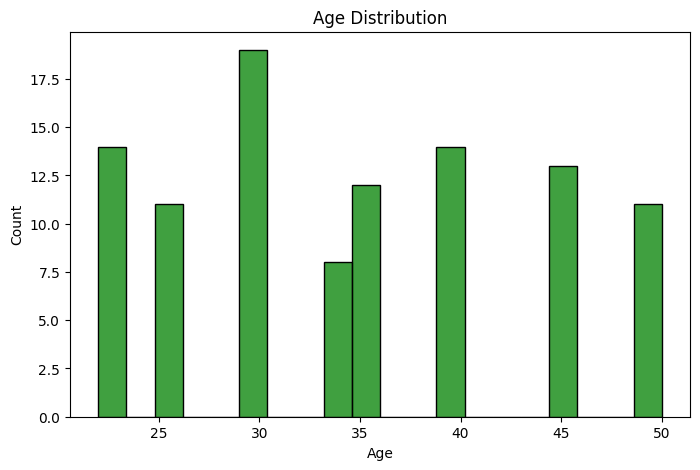

In [28]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20,color="Green")
plt.title("Age Distribution")
plt.show()

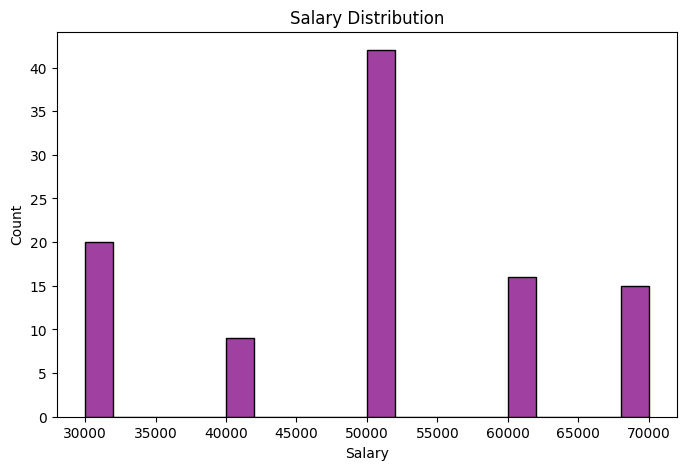

In [32]:
plt.figure(figsize=(8,5))
sns.histplot(df['Salary'], bins=20,color="purple")
plt.title("Salary Distribution")
plt.show()

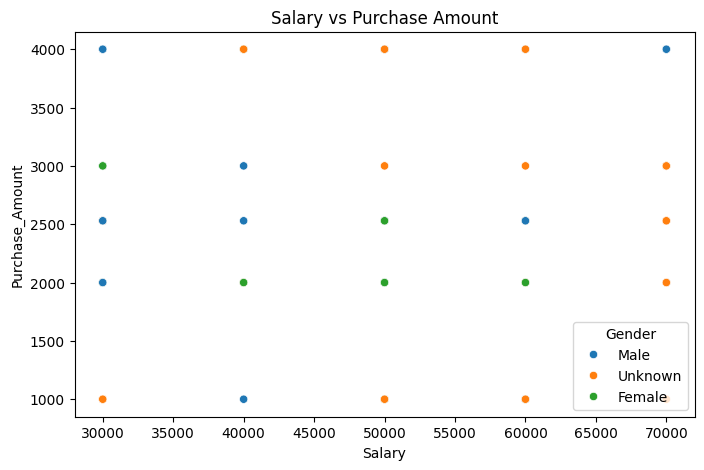

In [33]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Salary', y='Purchase_Amount', hue='Gender', data=df)
plt.title("Salary vs Purchase Amount")
plt.show()

In [35]:
avg_amount=df.groupby("City")["Purchase_Amount"].mean().reset_index()
print(avg_amount)

        City  Purchase_Amount
0  Bangalore      2080.610022
1      Delhi      2074.866310
2     Mumbai      2613.003096
3       Pune      3372.549020


/tmp/ipykernel_4806/3977511526.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_amount,x="City",y="Purchase_Amount",palette="viridis")


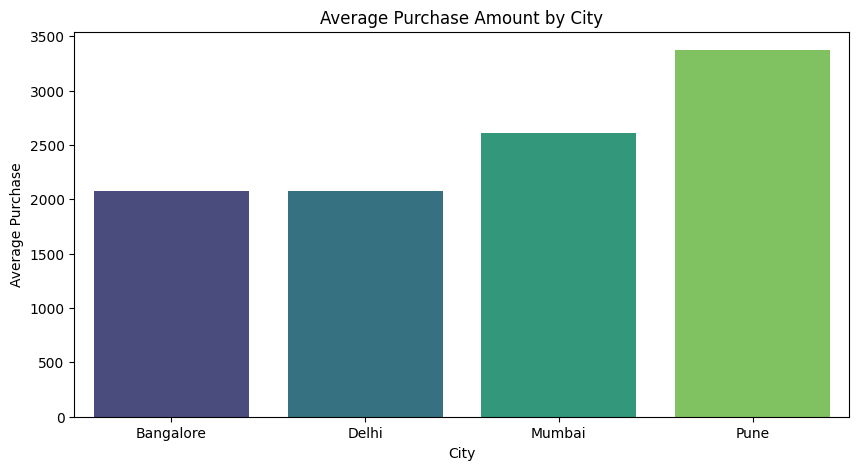

In [37]:
plt.figure(figsize=(10,5))
sns.barplot(data=avg_amount,x="City",y="Purchase_Amount",palette="viridis")
plt.title("Average Purchase Amount by City")
plt.ylabel("Average Purchase")
plt.show()